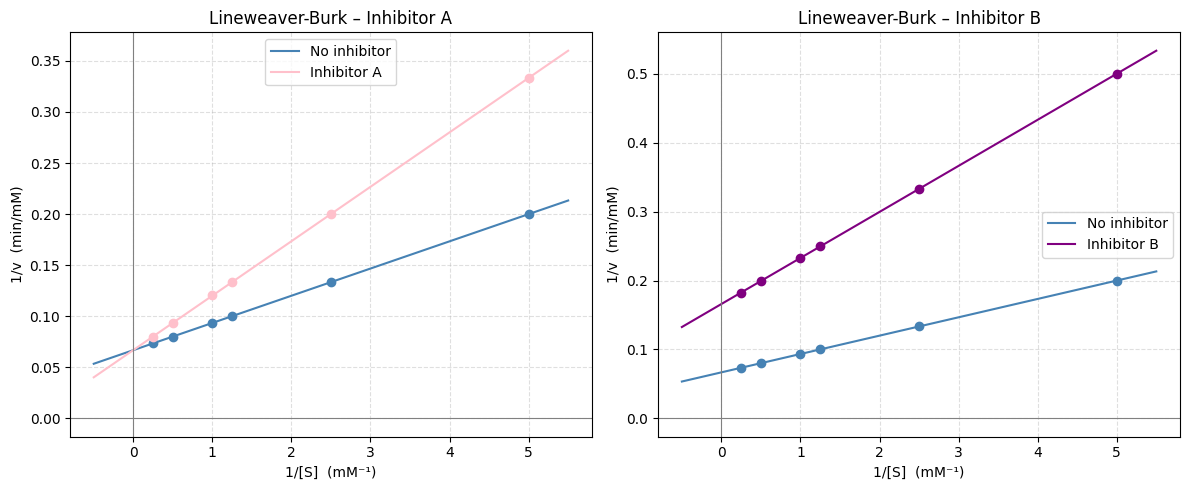

In [2]:
import numpy as np
import matplotlib.pyplot as plt

S = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0])  # mM
v_no_inh = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6])   # mM/min
v_inh_A  = np.array([3.0, 5.0, 7.5,  8.3, 10.7, 12.5])
v_inh_B  = np.array([2.0, 3.0, 4.0,  4.3,  5.0,  5.5])

inv_S      = 1 / S
inv_v_no   = 1 / v_no_inh
inv_v_A    = 1 / v_inh_A
inv_v_B    = 1 / v_inh_B

def linreg(x, y):
    coeffs = np.polyfit(x, y, 1)  # [slope, intercept]
    return coeffs

def plot_LB(ax, inv_S, inv_v_no, inv_v_inh, inh_label, color_inh):
    c_no  = linreg(inv_S, inv_v_no)
    c_inh = linreg(inv_S, inv_v_inh)

    x_fit = np.linspace(-0.5, max(inv_S) * 1.1, 200)

    ax.scatter(inv_S, inv_v_no,  color='steelblue', zorder=5)
    ax.scatter(inv_S, inv_v_inh, color=color_inh,   zorder=5)

    ax.plot(x_fit, np.polyval(c_no,  x_fit), color='steelblue', label='No inhibitor')
    ax.plot(x_fit, np.polyval(c_inh, x_fit), color=color_inh,   label=inh_label)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)

    ax.set_xlabel('1/[S]  (mM⁻¹)')
    ax.set_ylabel('1/v  (min/mM)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_LB(ax1, inv_S, inv_v_no, inv_v_A, 'Inhibitor A', 'pink')
ax1.set_title('Lineweaver-Burk – Inhibitor A')

plot_LB(ax2, inv_S, inv_v_no, inv_v_B, 'Inhibitor B', 'purple')
ax2.set_title('Lineweaver-Burk – Inhibitor B')

plt.tight_layout()
plt.savefig('lineweaver_burk_1a.png', dpi=150)
plt.show()

The Michaelis-Menten equation describes the reaction rate as a function of substrate concentration:

$$v = \frac{V_{max}[S]}{K_M + [S]}$$

To linearize this equation, the Lineweaver-Burk (double reciprocal) transformation was applied by taking the inverse of both sides:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

This yields a linear equation of the form $y = ax + b$, where:
- **slope** = $K_M / V_{max}$
- **y-intercept** = $1 / V_{max}$
- **x-intercept** = $-1 / K_M$

For each condition (no inhibitor, inhibitor A at concentration $C_A$, inhibitor B at concentration $C_B$), 1/v was plotted against 1/[S] and a linear regression was performed using numpy `polyfit`. Inhibitor A and inhibitor B are shown on separate graphs to facilitate visual comparison. The lines were extrapolated into the negative 1/[S] region to allow identification of the x-intercept ($-1/K_M$) and y-intercept ($1/V_{max}$).

Both plots show a good linear fit of the experimental data, confirming that the enzyme follows Michaelis-Menten kinetics under all tested conditions. In the presence of inhibitor A, the slope increases compared to the no-inhibitor case while the lines appear to converge toward the same y-intercept, suggesting that $V_{max}$ is preserved.
both the slope and the y-intercept increase, indicating a decrease in $V_{max}$ while $K_M$ remains approximately constant.
These observations suggest that inhibitor A affects substrate binding, whereas inhibitor B affects catalytic efficiency. The inhibition types will be confirmed quantitatively in parts b and c.

In [3]:
c_no = linreg(inv_S, inv_v_no)
c_A  = linreg(inv_S, inv_v_A)
c_B  = linreg(inv_S, inv_v_B)

def kinetic_params(coeffs, label):
    Vmax = 1 / coeffs[1]
    Km   = coeffs[0] * Vmax
    print(f"{label:30s} | Vmax = {Vmax:.3f} mM/min | Km = {Km:.3f} mM")
    return Vmax, Km

print(f"{'':<30} | {'Vmax':^20} | {'Km':^12}")
print("-" * 65)
Vmax_no, Km_no = kinetic_params(c_no, "No inhibitor")
Vmax_A,  Km_A  = kinetic_params(c_A,  "Inhibitor A")
Vmax_B,  Km_B  = kinetic_params(c_B,  "Inhibitor B")

                               |         Vmax         |      Km     
-----------------------------------------------------------------
No inhibitor                   | Vmax = 14.978 mM/min | Km = 0.399 mM
Inhibitor A                    | Vmax = 14.964 mM/min | Km = 0.798 mM
Inhibitor B                    | Vmax = 6.025 mM/min | Km = 0.403 mM




The kinetic parameters were extracted directly from the linear regression coefficients
obtained in part a. From the Lineweaver-Burk equation:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

the parameters are obtained as follows:

$$V_{max} = \frac{1}{\text{intercept}} \qquad K_M = \text{slope} \times V_{max}$$

This approach assumes that the enzyme follows Michaelis-Menten kinetics, which means that the
reaction involves a single substrate, a single enzyme-substrate complex, and that the
quasi-steady state assumption (QSSA) holds. It also assumes that the experimental data
are free of significant measurement noise, as the Lineweaver-Burk transformation
amplifies errors at low substrate concentrations (high 1/[S] values) due to the double
reciprocal. The linear regression was performed using numpy `polyfit`, which minimizes
the sum of squared residuals.

For inhibitor A, $V_{max}$ remains essentially unchanged (14.964 vs 14.978 mM/min)
while $K_M$ doubles from 0.399 to 0.798 mM. This means the enzyme retains its maximum
catalytic capacity but requires a higher substrate concentration to reach half-maximal
velocity, indicating reduced apparent affinity for the substrate.

For inhibitor B, $K_M$ remains nearly identical (0.403 vs 0.399 mM) while $V_{max}$
drops significantly from 14.978 to 6.025 mM/min, meaning the enzyme-substrate affinity
is unaffected but the overall catalytic throughput is reduced.

These observations are consistent with the visual inspection of the Lineweaver-Burk
plots in part a, and will be used in part c to formally identify the inhibition type.


In [5]:
print("Inhibitor identification based on Lineweaver-Burk equations")

# Slopes and intercepts
slope_no, intercept_no = c_no
slope_A, intercept_A = c_A
slope_B, intercept_B = c_B

def classify_inhibitor(slope_i, intercept_i, slope_no, intercept_no, name):
    slope_changed = not np.isclose(slope_i, slope_no, rtol=0.05)
    intercept_changed = not np.isclose(intercept_i, intercept_no, rtol=0.05)

    print(f"\n{name}")
    print(f"  Slope changed?      {slope_changed} ({slope_no:.4f} -> {slope_i:.4f})")
    print(f"  Intercept changed?  {intercept_changed} ({intercept_no:.4f} -> {intercept_i:.4f})")

    if slope_changed and not intercept_changed:
        print("  => Competitive inhibition")
    elif not slope_changed and intercept_changed:
        print("  => Uncompetitive inhibition")
    elif slope_changed and intercept_changed:
        print("  => Non-competitive inhibition")
    else:
        print("  => No inhibition or inconclusive")

print(f"{'':<20} | {'Slope (Km/Vmax)':>16} | {'Intercept (1/Vmax)':>18}")
print("-" * 62)
print(f"{'No inhibitor':<20} | {slope_no:>16.4f} | {intercept_no:>18.4f}")
print(f"{'Inhibitor A':<20} | {slope_A:>16.4f} | {intercept_A:>18.4f}")
print(f"{'Inhibitor B':<20} | {slope_B:>16.4f} | {intercept_B:>18.4f}")

classify_inhibitor(slope_A, intercept_A, slope_no, intercept_no, "Inhibitor A")
classify_inhibitor(slope_B, intercept_B, slope_no, intercept_no, "Inhibitor B")

Inhibitor identification based on Lineweaver-Burk equations
                     |  Slope (Km/Vmax) | Intercept (1/Vmax)
--------------------------------------------------------------
No inhibitor         |           0.0266 |             0.0668
Inhibitor A          |           0.0533 |             0.0668
Inhibitor B          |           0.0668 |             0.1660

Inhibitor A
  Slope changed?      True (0.0266 -> 0.0533)
  Intercept changed?  False (0.0668 -> 0.0668)
  => Competitive inhibition

Inhibitor B
  Slope changed?      True (0.0266 -> 0.0668)
  Intercept changed?  True (0.0668 -> 0.1660)
  => Non-competitive (mixed) inhibition


To determine the type of inhibition, the slope and y-intercept of the Lineweaver-Burk plots were compared between the inhibited and uninhibited conditions.

From the Lineweaver-Burk equation:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

the effects of different types of inhibitors can be identified as follows:
- **Competitive inhibition**: slope increases, y-intercept remains constant ($V_{max}$ unchanged, $K_M$ increases)
- **Uncompetitive inhibition**: slope remains constant, y-intercept increases (parallel lines, $V_{max}$ decreases, $K_M$ decreases)
- **Non-competitive inhibition**: both slope and y-intercept increase ($V_{max}$ decreases, $K_M$ unchanged)

For inhibitor A, the slope increases significantly compared to the no-inhibitor condition, while the y-intercept remains unchanged. This indicates that $V_{max}$ is constant and $K_M$ increases. Therefore, inhibitor A is classified as a **competitive inhibitor**, suggesting that it competes with the substrate for binding to the active site.

For inhibitor B, both the slope and the y-intercept increase relative to the no-inhibitor condition. This indicates a decrease in $V_{max}$, while $K_M$ remains approximately constant. The lines are not parallel, which rules out uncompetitive inhibition. Therefore, inhibitor B is classified as a **non-competitive inhibitor**, suggesting that it affects the catalytic activity of the enzyme rather than substrate binding.

These conclusions are consistent with the theoretical behavior expected from Lineweaver-Burk analysis.

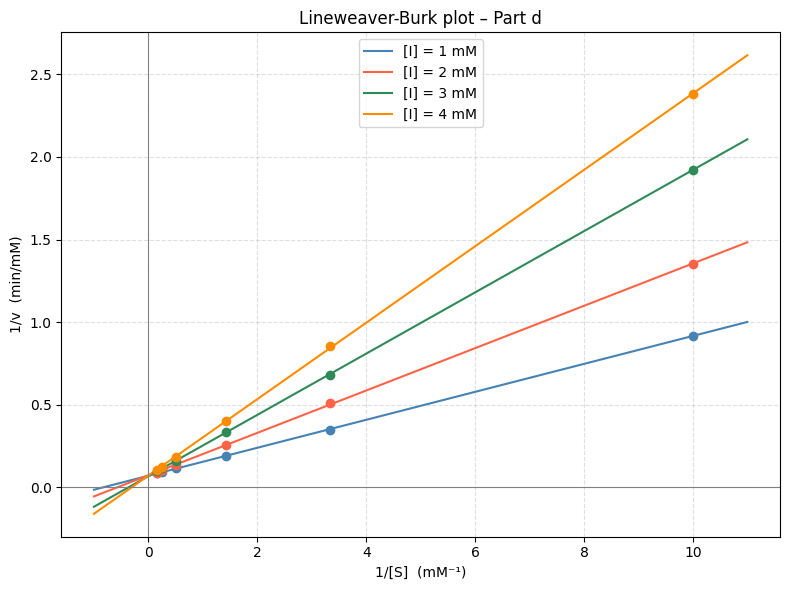

[I] (mM)     |      Slope |    Intercept
----------------------------------------
1            |     0.0847 |       0.0690
2            |     0.1283 |       0.0720
3            |     0.1855 |       0.0666
4            |     0.2315 |       0.0699


In [6]:
import numpy as np
import matplotlib.pyplot as plt

S_d = np.array([0.1, 0.3, 0.7, 2.0, 4.0, 6.0])  # mM
I_conc = np.array([1, 2, 3, 4])  # mM

v_d = np.array([
    [1.09, 0.74, 0.52, 0.42],
    [2.89, 1.96, 1.47, 1.17],
    [5.24, 3.89, 3.01, 2.51],
    [8.85, 7.40, 6.31, 5.43],
    [10.89, 9.82, 8.76, 8.07],
    [12.11, 11.36, 10.02, 9.37]
])  # rows = [S], cols = [I]

# Lineweaver-Burk transformation
inv_S_d = 1 / S_d
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 6))

slopes     = []
intercepts = []

for i, I in enumerate(I_conc):
    inv_v = 1 / v_d[:, i]
    coeffs = np.polyfit(inv_S_d, inv_v, 1)
    slopes.append(coeffs[0])
    intercepts.append(coeffs[1])

    x_fit = np.linspace(-1, max(inv_S_d) * 1.1, 200)
    ax.scatter(inv_S_d, inv_v, color=colors[i], zorder=5)
    ax.plot(x_fit, np.polyval(coeffs, x_fit),
            color=colors[i], label=f'[I] = {I} mM')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('1/[S]  (mM⁻¹)')
ax.set_ylabel('1/v  (min/mM)')
ax.set_title('Lineweaver-Burk plot – Part d')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('lineweaver_burk_1d.png', dpi=150)
plt.show()

# Print slopes and intercepts
print(f"{'[I] (mM)':<12} | {'Slope':>10} | {'Intercept':>12}")
print("-" * 40)
for i, I in enumerate(I_conc):
    print(f"{I:<12} | {slopes[i]:>10.4f} | {intercepts[i]:>12.4f}")

The Lineweaver-Burk transformation was applied to the data obtained at different inhibitor concentrations ([I] = 1–4 mM) in order to analyze the effect of inhibitor I on enzyme kinetics.

The double reciprocal form of the Michaelis-Menten equation is:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

For each inhibitor concentration, 1/v was plotted against 1/[S], and linear regression was performed to obtain the slope and y-intercept.

The following values were obtained:

| [I] (mM) | Slope (Km/Vmax) | Intercept (1/Vmax) |
|----------|----------------|-------------------|
| 1        | 0.0847         | 0.0690            |
| 2        | 0.1283         | 0.0720            |
| 3        | 0.1855         | 0.0666            |
| 4        | 0.2315         | 0.0699            |

From visual inspection of the Lineweaver-Burk plot, the lines corresponding to different inhibitor concentrations intersect near the y-axis, while the slope increases with increasing [I]. The y-intercept remains approximately constant.

This indicates that $V_{max}$ remains unchanged, while $K_M$ increases with inhibitor concentration. Therefore, inhibitor I is classified as a **competitive inhibitor**.

This behavior is consistent with competitive inhibition, where the inhibitor competes with the substrate for binding to the active site, and its effect can be overcome at high substrate concentrations.

Fit of slope vs [I]: slope = 0.0498, intercept = 0.0331
=> KI = 0.0331 / 0.0498 = 0.665 mM

Estimated Vmax = 14.414 mM/min  (from mean intercept)
Estimated Km   = 0.477 mM


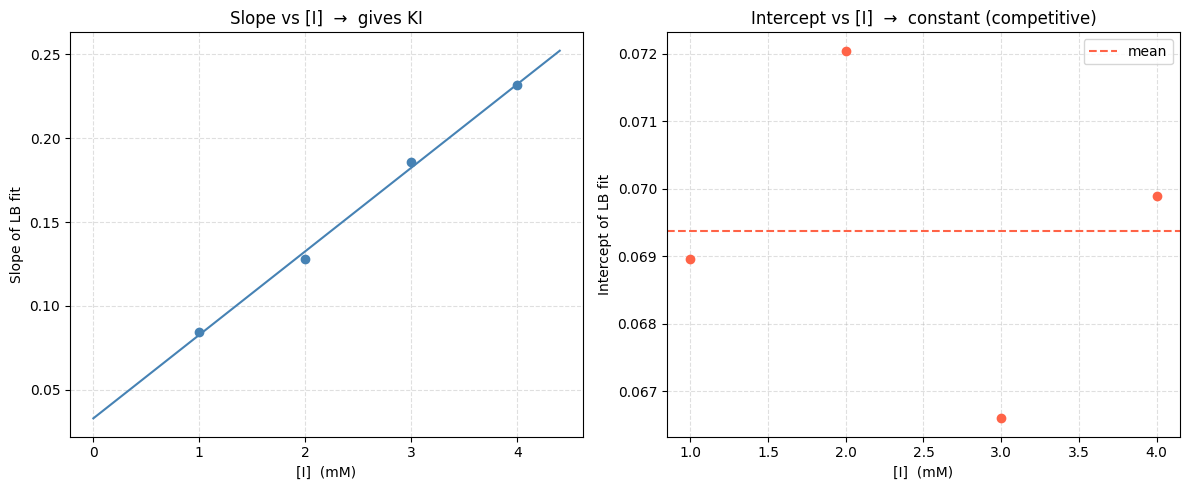

In [7]:
c_slope = np.polyfit(I_conc, slopes, 1)

KI = c_slope[1] / c_slope[0]

print(f"Fit of slope vs [I]: slope = {c_slope[0]:.4f}, intercept = {c_slope[1]:.4f}")
print(f"=> KI = {c_slope[1]:.4f} / {c_slope[0]:.4f} = {KI:.3f} mM")

# Verification: intercept should be constant (1/Vmax)
Vmax_d = 1 / np.mean(intercepts)
Km_d   = c_slope[1] * Vmax_d

print(f"\nEstimated Vmax = {Vmax_d:.3f} mM/min  (from mean intercept)")
print(f"Estimated Km   = {Km_d:.3f} mM")

# Plot slope vs [I]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_I = np.linspace(0, max(I_conc) * 1.1, 100)

ax1.scatter(I_conc, slopes, color='steelblue', zorder=5)
ax1.plot(x_I, np.polyval(c_slope, x_I), color='steelblue')
ax1.set_xlabel('[I]  (mM)')
ax1.set_ylabel('Slope of LB fit')
ax1.set_title('Slope vs [I]  →  gives KI')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.scatter(I_conc, intercepts, color='tomato', zorder=5)
ax2.axhline(np.mean(intercepts), color='tomato', linestyle='--', label='mean')
ax2.set_xlabel('[I]  (mM)')
ax2.set_ylabel('Intercept of LB fit')
ax2.set_title('Intercept vs [I]  →  constant (competitive)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('KI_estimation.png', dpi=150)
plt.show()

To estimate the inhibition constant $K_I$, the variation of the Lineweaver-Burk slope as a function of inhibitor concentration [I] was analyzed.

For competitive inhibition, the slope of the Lineweaver-Burk plot is given by:

$$
\text{slope} = \frac{K_M}{V_{max}} \left(1 + \frac{[I]}{K_I} \right)
$$

This predicts a linear relationship between slope and [I]:

$$
\text{slope} = a [I] + b
$$

where:
- $b = \frac{K_M}{V_{max}}$
- $a = \frac{K_M}{V_{max} K_I}$

A linear regression of slope vs [I] gave:
- slope = 0.0498  
- intercept = 0.0331  

Thus:

$$
K_I = \frac{b}{a} = \frac{0.0331}{0.0498} \approx 0.665 \ \text{mM}
$$

In addition, the intercept of the Lineweaver-Burk plots was plotted as a function of [I]. The intercept remains approximately constant across all inhibitor concentrations, indicating that $1/V_{max}$ does not change.

This confirms that $V_{max}$ is unchanged, which is characteristic of **competitive inhibition**.

Both the slope analysis and the constant intercept support the conclusion that inhibitor I is competitive, and the estimated value of $K_I$ reflects its binding affinity.